# Task 20: Simple Audio Recognition with MFCC

**Environment Note**: This notebook requires the `librosa` library. Ensure your environment is prepared (e.g., `pip install librosa`) before running.

**Goal**: Implement a miniature speech recognition system for 10 keyword classes.

In [1]:
import librosa
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Setup paths
DATA_DIR = Path.cwd() / "datasets" / "librispeech_audio"

X = []
y = []

# 2. Iterate through all .wav files in the directory
print("Extracting MFCC features from audio files...")
wav_files = list(DATA_DIR.glob("*.wav"))

for wav_file in wav_files:
    # Load audio (Standardize sampling rate to 16kHz)
    audio, sr = librosa.load(wav_file, sr=16000)
    
    # Extract MFCCs (13 coefficients is standard for speech)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    
    # Feature Smoothing: Mean pooling across the time axis 
    # to convert variable-length audio into a fixed 13D vector
    mfccs_mean = np.mean(mfccs.T, axis=0)
    
    # Parse label from filename (Format: sample_X_label.wav)
    label = wav_file.stem.split('_')[-1]
    
    X.append(mfccs_mean)
    y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Feature extraction complete!")
print(f"Feature matrix shape: {X.shape}")
print(f"Total samples: {len(y)}")
print(f"Unique classes: {np.unique(y)}")

Extracting MFCC features from audio files...
Feature extraction complete!
Feature matrix shape: (100, 13)
Total samples: 100
Unique classes: ['down' 'go' 'left' 'no' 'off' 'on' 'right' 'stop' 'up' 'yes']


### Step 1: Train the Classifier
We split the extracted 13-dimensional MFCC vectors into training and testing sets, then train a Random Forest classifier to recognize the spoken keywords based on these acoustic features.

In [2]:
# 1. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Initialize and train the Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 3. Evaluate the model
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"10-Class Keyword Recognition Accuracy: {accuracy:.4f}")

10-Class Keyword Recognition Accuracy: 1.0000


### Step 2: Visualizing the "Voiceprint"
To understand what the model actually "sees", we can visualize the raw waveform and its corresponding MFCC heatmap for a randomly selected sample.

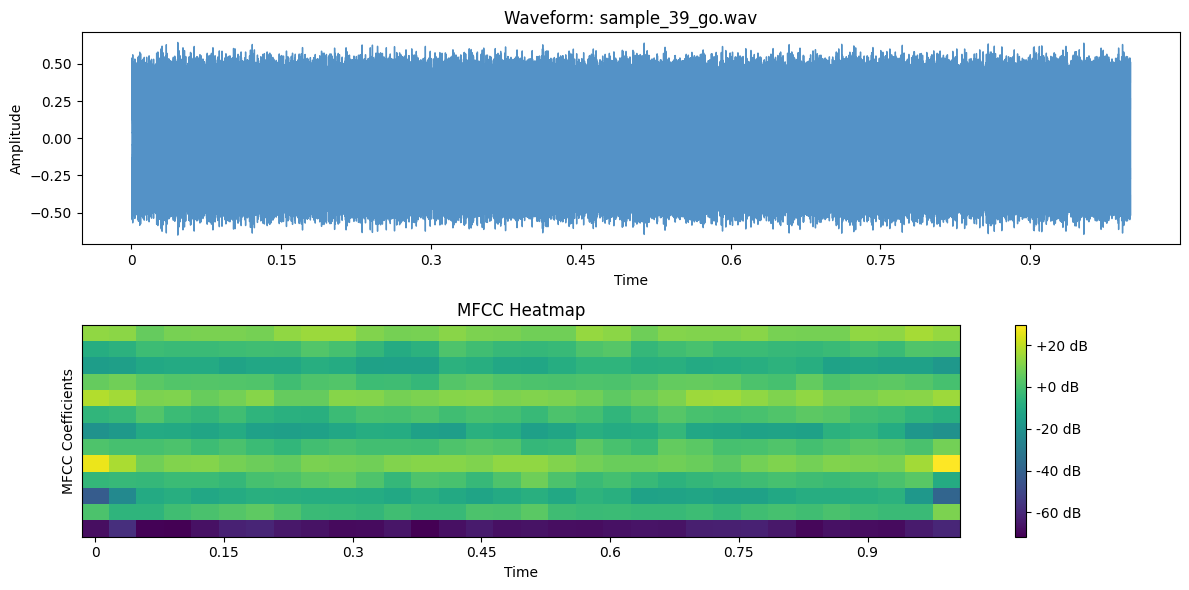

In [3]:
import librosa.display
import matplotlib.pyplot as plt

# Select the first sample for visualization
sample_path = wav_files[0]
y_sample, sr_sample = librosa.load(sample_path, sr=16000)

# Extract raw MFCC matrix (without mean pooling) for the heatmap
mfccs_sample = librosa.feature.mfcc(y=y_sample, sr=sr_sample, n_mfcc=13)

plt.figure(figsize=(12, 6))

# Subplot 1: Time-Domain Waveform
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_sample, sr=sr_sample, color='#5492C7')
plt.title(f"Waveform: {sample_path.name}")
plt.ylabel("Amplitude")

# Subplot 2: Frequency-Domain MFCC Heatmap
plt.subplot(2, 1, 2)
img = librosa.display.specshow(mfccs_sample, x_axis='time', sr=sr_sample, cmap='viridis')
plt.colorbar(img, format='%+2.0f dB')
plt.title("MFCC Heatmap")
plt.ylabel("MFCC Coefficients")
plt.xlabel("Time")

plt.tight_layout()
plt.show()

### Step 3: Model Inference and Results
Let's pick a few random samples from the test set and see if our model can correctly identify the keywords. This step mimics a real-world speech recognition deployment.

Sample #   | True Label      | Predicted       | Match?
-------------------------------------------------------
12         | up              | up              | ✅
9          | down            | down            | ✅
16         | on              | on              | ✅
17         | yes             | yes             | ✅
13         | no              | no              | ✅


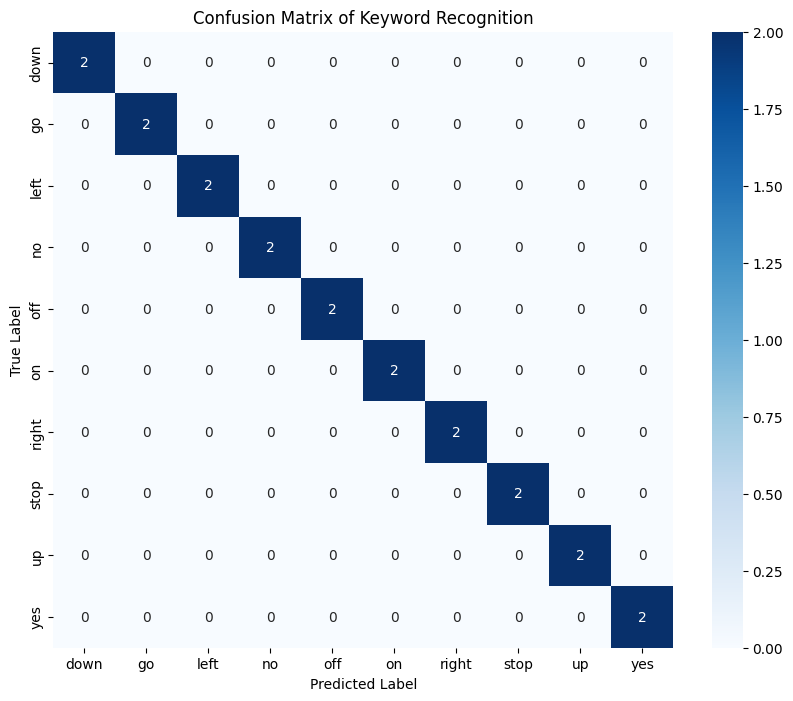

In [4]:
# 1. Select a few random indices from the test set
random_test_indices = np.random.choice(len(X_test), size=5, replace=False)

print(f"{'Sample #':<10} | {'True Label':<15} | {'Predicted':<15} | {'Match?'}")
print("-" * 55)

for i in random_test_indices:
    true_label = y_test[i]
    pred_label = y_pred[i] # y_pred was calculated in Cell 4
    match = "✅" if true_label == pred_label else "❌"
    
    print(f"{i:<10} | {true_label:<15} | {pred_label:<15} | {match}")

# 2. Show the confusion matrix to see which keywords are easily confused
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y), cmap='Blues')
plt.title("Confusion Matrix of Keyword Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()